In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline

import csv


# Functions

In [2]:
def comma_to_left(string, index) -> bool:
    '''
    Checks if there is a comma to the left of the index in the string, ignoring spaces.
    '''
    while index >= 1:
        if string[index - 1] == ',':
            return True
        if string[index - 1] == ' ':
            index -= 1
        else:
            return False
    return False

def strip_optional_tags(string):
    '''
    Strips "optional" tags from the string, and strips descriptions of ingredients in parentheses
    '''
    # First, remove simple substrings
    string = string.replace("[", "").replace("]", "")
    string = string.replace("optionally", "").replace("optional", "")
    string = string.replace(":", "")
    
    # Handle parentheses: find all "("s
    # If no comma to the left, delete everything from "(" to ")"
    # If comma to the left, just delete "(" and ")"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            
            # Check if there's a comma to the left
            if comma_to_left(string, i):
                # Just delete "(" and ")", keep the content
                result.append(string[i+1:close_idx])
                i = close_idx + 1
            else:
                # Delete all text from "(" to ")" inclusive
                i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result)

def strip_optional_ingredients(string): # MAY NOT WORK
    '''
    Strips "optional" ingredients from the string, as well as descriptions of ingredients in parentheses.
    '''
    # First pass: Look for "(" or "[" from left to right
    # If one is found and there's a comma to the left, delete everything from that comma to the end
    i = 0
    while i < len(string):
        if string[i] in '([':
            if comma_to_left(string, i):
                # Delete everything from the comma to the end of the string
                j = i - 1
                while j >= 0:
                    if string[j] == ',':
                        string = string[:j]
                        break
                    j -= 1
                break
        i += 1
    
    # Second pass: Search for "(optional)" and "[optional]" repeatedly
    while True:
        idx1 = string.find("(optional)")
        idx2 = string.find("[optional]")
        
        if idx1 == -1 and idx2 == -1:
            break
        
        # Find which one comes first
        idx = -1
        pattern_len = 0
        if idx1 != -1 and idx2 != -1:
            idx = min(idx1, idx2)
            pattern_len = 10 if idx == idx1 else 10
        elif idx1 != -1:
            idx = idx1
            pattern_len = 10
        else:
            idx = idx2
            pattern_len = 10
        
        # Find the first comma to the left, delete from comma to end of pattern
        j = idx - 1
        comma_idx = -1
        while j >= 0:
            if string[j] == ',':
                comma_idx = j
                break
            j -= 1
        
        if comma_idx != -1:
            # Delete from comma to the end of the pattern
            string = string[:comma_idx] + string[idx + pattern_len:]
        else:
            # No comma found, just remove the pattern
            string = string[:idx] + string[idx + pattern_len:]
    
    # Final pass: Strip everything in parentheses, including the parentheses themselves
    # get rid of the descriptions of ingredients in parentheses, e.g. "kalabasa (squash)"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            # Skip everything from "(" to ")" inclusive
            i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result).strip()


def clean_ingredient_list(string):
    '''
    Strips whitespace and empty ingredients so that we can easily split by comma to get a clean list
    Also splits on "and", "or" and "/" and removes periods
    '''
    normalized = re.sub(r"\bor\b", ",", string, flags=re.IGNORECASE)
    normalized = re.sub(r"\band\b", ",", normalized, flags=re.IGNORECASE)
    normalized = re.sub(r"/", ",", normalized, flags=re.IGNORECASE)
    return [ingredient.lower().replace(".", "").strip() for ingredient in normalized.split(",") if ingredient.strip()]

def countries_to_array(string):
    '''
    Converts a string of countries separated by semicolons into an array of countries, stripping whitespace.
    '''
    return [country.strip() for country in string.split(";") if country.strip()]

## Testing

In [4]:
print(strip_optional_tags("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_tags("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_tags("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_tags("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_tags("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_tags("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_tags("salt, (optional garlic), (optional sugar)"))
print(strip_optional_tags("salt, kalabasa (squash)"))
print(strip_optional_tags("salt, kalabasa (squash), (optional) garlic"))

print("\n" + strip_optional_tags("salt, sugar, (optionally pepper), (optional garlic)"))
print(strip_optional_tags("Cold noodles, sliced beef, beef broth, kimchi, boiled egg, cucumber, radish, (optional pickled mustard greens, optional apple slices, optional sesame seeds)."))
print(strip_optional_tags("salt, (mushrooms optional), (peas optional),"))

salt, sugar, pepper , garlic , onion 
salt,  garlic, sugar, etc.
salt, sugar, pepper , garlic , onion 
salt, sugar,  pepper,  garlic,  onion
salt, green onions , red onions 
salt,  garlic,  sugar
salt,  garlic,  sugar
salt, kalabasa 
salt, kalabasa ,  garlic

salt, sugar,  pepper,  garlic
Cold noodles, sliced beef, beef broth, kimchi, boiled egg, cucumber, radish,  pickled mustard greens,  apple slices,  sesame seeds.
salt, mushrooms , peas ,


In [8]:
print(strip_optional_ingredients("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_ingredients("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_ingredients("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_ingredients("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_ingredients("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_ingredients("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_ingredients("salt, (optional garlic), (optional sugar)"))
print(strip_optional_ingredients("salt, kalabasa (squash)"))
print(strip_optional_ingredients("salt, kalabasa (squash), (optional) garlic"))

salt, sugar
salt
salt, sugar
salt, sugar
salt
salt
salt
salt, kalabasa
salt, kalabasa


In [9]:
clean_ingredient_list("salt   , meat or fish,     onion, etc")

['salt', 'meat', 'fish', 'onion', 'etc']

# Data Cleaning

### Overview / optional ingredient processing

In [10]:
df = pd.read_csv('data.csv')

cleaned_df = df.copy().drop("alternate_names", axis=1)

cleaned_df['ingredients'] = cleaned_df['ingredients'].apply(strip_optional_tags).apply(clean_ingredient_list)
cleaned_df['countries_of_origin'] = cleaned_df['countries_of_origin'].apply(countries_to_array)

In [11]:
cleaned_df.head()

,dish_name,countries_of_origin,ingredients
0,Cepelinai,[Lithuania],"[potatoes, ground meat, onions, bacon, sour cr..."
1,Msabbaha,"[Oman, Jordan, Bahrain, Palestine, Qatar, Unit...","[chickpeas, tahini, lemon juice, garlic, olive..."
2,Lazarakia,"[Greece, Cyprus]","[flour, yeast, water, sugar, olive oil, salt, ..."
3,Dressed Crab,[United Kingdom],"[crab meat, mayonnaise, lemon juice, breadcrum..."
4,Dak-galbi,[South Korea],"[chicken, gochujang, soy sauce, garlic, ginger..."


In [12]:
cleaned_df['countries_of_origin'].explode().value_counts().head(15) / len(cleaned_df) * 100.0

countries_of_origin
United States     6.56
Japan             4.80
China             4.68
Philippines       4.48
Indonesia         4.44
United Kingdom    4.24
Italy             4.20
India             3.72
Spain             3.48
France            3.36
South Korea       3.32
Germany           3.24
Canada            3.08
Turkey            2.52
North Korea       2.44
Name: count, dtype: float64

In [13]:
# filter out duplicates
unique_dishes_df = cleaned_df.drop_duplicates(subset=['dish_name'])
len(unique_dishes_df)

1572

<Axes: xlabel='count', ylabel='Count'>

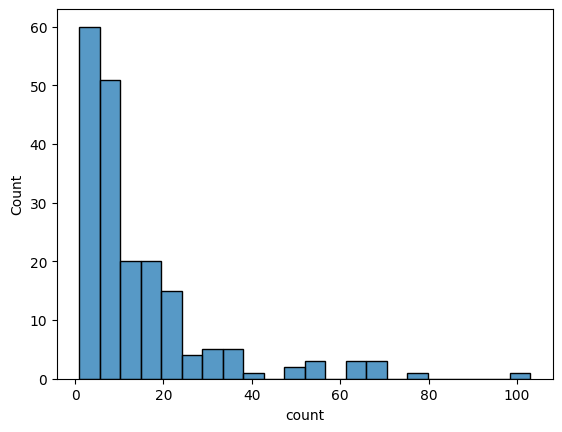

In [14]:
sns.histplot(unique_dishes_df['countries_of_origin'].explode().value_counts())

### Collapse similar ingredient variants (plural, spacing, accents, etc.)

In [15]:
import inflect
import unicodedata
import re

p = inflect.engine()

# Normalize ingredient strings to collapse accent, apostrophe, and hyphen variants,
# while preserving spaces so canonical multi-word ingredients stay spaced.
def normalize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    ingredient = unicodedata.normalize('NFKD', ingredient)
    ingredient = ''.join(ch for ch in ingredient if not unicodedata.combining(ch))
    ingredient = ingredient.lower()
    ingredient = ingredient.replace('-', ' ')
    ingredient = re.sub(r"[’`´]", "'", ingredient)
    ingredient = ingredient.replace("'", '')
    ingredient = re.sub(r'\s+', ' ', ingredient).strip()
    return ingredient

# Singularize ingredients after normalization
def singularize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    ingredient = normalize_ingredient(ingredient)
    try:
        return p.singular_noun(ingredient) or ingredient
    except Exception:
        return ingredient

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [singularize_ingredient(ing) for ing in lst]
)

# Map joined variants to spaced canonical forms when a spaced form exists.
joined_to_spaced = {}
for ing in unique_dishes_df.loc[:, 'ingredients'].explode().dropna().unique():
    joined = ing.replace(' ', '')
    if ' ' in ing:
        joined_to_spaced[joined] = ing

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [joined_to_spaced.get(ing.replace(' ', ''), ing) for ing in lst]
)


In [16]:
from fuzzywuzzy import fuzz
from itertools import combinations

ingredients = unique_dishes_df['ingredients'].explode().dropna().unique()
pairs = list(combinations(ingredients, 2))

# Calculate similarities
similarities = [(pair, fuzz.ratio(pair[0], pair[1])) for pair in pairs]
similarities.sort(key=lambda x: x[1], reverse=True)

In [17]:
similarities[:40]

[(('pomegranate seed', 'pomgranate seed'), 97),
 (('sausage casing', 'sausages casing'), 97),
 (('corn starch', 'acorn starch'), 96),
 (('chili sauce', 'chilli sauce'), 96),
 (('sheep casing', 'sheeps casing'), 96),
 (('goats milk', 'goat milk'), 95),
 (('sheep milk', 'sheeps milk'), 95),
 (('pig blood', 'pigs blood'), 95),
 (('pig tail', 'pigs tail'), 94),
 (('cows milk', 'cow milk'), 94),
 (('red chili pepper', 'dried chili pepper'), 94),
 (('gelatin', 'gelatine'), 93),
 (('spaetzle', 'spatzle'), 93),
 (('sodium nitrite', 'sodium nitrate'), 93),
 (('habanero pepper', 'habenero pepper'), 93),
 (('chili pepper', 'chile pepper'), 92),
 (('dried shrimp', 'fried shrimp'), 92),
 (('pasilla chili', 'pasilla chile'), 92),
 (('artificial flavoring', 'artificial flavor'), 92),
 (('locoto pepper', 'rocoto pepper'), 92),
 (('green chili', 'green chile'), 91),
 (('powdered sugar for dusting', 'powdered sugar for frosting'), 91),
 (('nopale', 'nopal'), 91),
 (('dried fish', 'fried fish'), 90),
 ((

In [18]:
unique_dishes_df['ingredients'].explode().value_counts().head(10)

ingredients
salt      877
garlic    648
onion     553
sugar     476
water     382
egg       343
butter    331
pepper    311
flour     269
tomato    243
Name: count, dtype: int64

### Trying to make connections between base and processed ingredient names...

In [19]:
ingredients = unique_dishes_df['ingredients'].explode()

one_word_ingredients = ingredients[ingredients.str.split().str.len() == 1]

len(one_word_ingredients.value_counts())


570

In [20]:
most_common_200 = one_word_ingredients.value_counts().head(200).index.tolist()
# if one of words of ingredients of dish is in the most common 50 ingredients, add the one-word ingredient to the dish's ingredient list (if not already present)
def get_base_ingredient_names(ingredient_list):
    base_ingredients = []
    for ingredient in ingredient_list:
        for word in ingredient.split():
            if word in most_common_200 and word not in base_ingredients:
                base_ingredients.append(word)
    return base_ingredients

def add_base_ingredients(ingredient_list):
    base_ingredients = get_base_ingredient_names(ingredient_list)
    return list(set(ingredient_list) | set(base_ingredients))

In [21]:
add_base_ingredients(["green onion", "red onion", "minced garlic", "garlic", "chicken", "rice", "ube jam"])

['chicken',
 'minced garlic',
 'onion',
 'garlic',
 'rice',
 'jam',
 'green onion',
 'ube jam',
 'red onion']

In [22]:
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(add_base_ingredients)
unique_dishes_df.loc[0, 'ingredients']

['salt',
 'ground meat',
 'onion',
 'pepper',
 'meat',
 'dill',
 'egg',
 'cream',
 'bacon',
 'potato',
 'sour cream',
 'garlic',
 'mushroom']

### misc

In [23]:
def display_ingredients(dish_name):
    ingredients = cleaned_df.loc[cleaned_df['dish_name'] == dish_name, 'ingredients'].values
    if len(ingredients) > 0:
        return ", ".join(ingredients[0])
    else:
        return []

# Models

### Train/test split + conversion to multiclass classification from multilabel

In [24]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

# Keep the full multi-country lists for evaluation, but split before assigning single labels.
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()
train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)

# Compute the most common country labels from the training set only.
train_country_counts = train_df['countries_of_origin'].explode().value_counts()

def most_common_country(country_list):
    if not country_list:
        return np.nan
    ranked = sorted(country_list, key=lambda c: train_country_counts.get(c, 0), reverse=True)
    return ranked[0]

# convert multi-label to single-label for training by taking the most common country in the training set among the valid countries for each dish
#train_df['target_country'] = train_df['countries_of_origin'].apply(most_common_country)

# expand multi-labels into separate rows for training, 1 row per dish-country_of_origin pair
train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)

# filter out less common countries from the training set to reduce noise
uncommon_countries = train_country_counts.tail(150).index
train_df = train_df[~train_df['target_country'].isin(uncommon_countries)]


mlb = MultiLabelBinarizer(sparse_output=False)
mlb.fit(model_df['ingredients'])
X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

y_train = train_df['target_country']
y_test_multi = test_df['countries_of_origin']

print('Training rows:', len(train_df))
print('Test rows:', len(test_df))
print('Training country counts:', y_train.value_counts().head(10).to_dict())
print('Example test labels (multi-country):', y_test_multi.head().tolist())


Training rows: 1268
Test rows: 315
Training country counts: {'United States': 85, 'Japan': 66, 'Indonesia': 55, 'United Kingdom': 54, 'China': 51, 'India': 51, 'Italy': 49, 'Philippines': 48, 'Spain': 47, 'Germany': 44}
Example test labels (multi-country): [['Bulgaria', 'Turkey'], ['Australia', 'New Zealand', 'United Kingdom', 'Canada'], ['Bangladesh'], ['United Kingdom'], ['Italy']]


### Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# example display count
n = 8
display_ings = False

clf = DecisionTreeClassifier(max_depth = 150, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())


Train set: (1268, 2164) Test set: (315, 2164)
Hold-out accuracy (single-label prediction vs. any true country): 0.2507936507936508

Predicted vs actual multi-country labels for first examples:
Nokul: predicted Algeria, actual=['Bulgaria', 'Turkey'], incorrect
Bacon And Egg Pie: predicted Peru, actual=['Australia', 'New Zealand', 'United Kingdom', 'Canada'], incorrect
Chunga Pitha: predicted India, actual=['Bangladesh'], incorrect
Haggis: predicted Sweden, actual=['United Kingdom'], incorrect
Bagna Càuda: predicted Spain, actual=['Italy'], incorrect
Baccalà Alla Lucana: predicted Italy, actual=['Italy'], correct
Egg Bhurji: predicted India, actual=['Bhutan', 'Pakistan', 'Sri Lanka', 'Nepal', 'Bangladesh', 'Maldives', 'India'], correct
Pescado Frito: predicted Spain, actual=['Spain'], correct

Top ingredient importances:
shallot       0.019719
mirin         0.018607
olive oil     0.015869
egg           0.015503
sugar         0.015356
flour         0.014835
ghee          0.013509
milk    

In [26]:
display_ingredients('Qarymutah')

'bulgur, onion, cucumber, tomato, parsley, lemon juice, mint, sumac'

How did it go USA.........

In [27]:
y_train[y_train == 'Syria']

Series([], Name: target_country, dtype: object)

It turns out setting the training label to the most frequent of the valid countries filters out Syria entirely

### Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

# example display count
n = 8
display_ings = False

clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1268, 2164) Test set: (315, 2164)
Hold-out accuracy (single-label prediction vs. any true country): 0.35873015873015873

Predicted vs actual multi-country labels for first examples:
Nokul: predicted Canada, actual=['Bulgaria', 'Turkey'], incorrect
Bacon And Egg Pie: predicted United States, actual=['Australia', 'New Zealand', 'United Kingdom', 'Canada'], incorrect
Chunga Pitha: predicted India, actual=['Bangladesh'], incorrect
Haggis: predicted United Kingdom, actual=['United Kingdom'], correct
Bagna Càuda: predicted Italy, actual=['Italy'], correct
Baccalà Alla Lucana: predicted Italy, actual=['Italy'], correct
Egg Bhurji: predicted India, actual=['Bhutan', 'Pakistan', 'Sri Lanka', 'Nepal', 'Bangladesh', 'Maldives', 'India'], correct
Pescado Frito: predicted Italy, actual=['Spain'], incorrect

Top ingredient importances:
water           0.011751
egg             0.011466
oil             0.011106
rice            0.010318
salt            0.010251
olive oil       0.009872
onio

In [29]:
pd.Series(y_pred).value_counts() / len(y_pred) * 100

Germany           10.158730
United Kingdom     9.523810
Italy              6.984127
Philippines        6.984127
Spain              5.714286
United States      5.714286
India              5.079365
South Korea        4.444444
Thailand           4.126984
Japan              4.126984
France             3.174603
Mexico             2.857143
China              2.857143
Brazil             2.539683
Canada             2.539683
Indonesia          2.222222
Australia          1.904762
Colombia           1.904762
Vietnam            1.904762
Iran               1.904762
Turkey             1.587302
North Korea        1.269841
Georgia            1.269841
Sweden             1.269841
Algeria            0.952381
Taiwan             0.952381
Azerbaijan         0.952381
Tunisia            0.952381
Poland             0.952381
Romania            0.634921
Peru               0.634921
Pakistan           0.634921
Malaysia           0.317460
Egypt              0.317460
Russia             0.317460
Hong Kong          0

### Balanced Random Forest

In [30]:
from imblearn.ensemble import BalancedRandomForestClassifier

# example display count
n = 8
display_ings = False

clf = BalancedRandomForestClassifier(random_state=42, n_estimators=300, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1268, 2164) Test set: (315, 2164)
Hold-out accuracy (single-label prediction vs. any true country): 0.30793650793650795

Predicted vs actual multi-country labels for first examples:
Nokul: predicted Tunisia, actual=['Bulgaria', 'Turkey'], incorrect
Bacon And Egg Pie: predicted United States, actual=['Australia', 'New Zealand', 'United Kingdom', 'Canada'], incorrect
Chunga Pitha: predicted India, actual=['Bangladesh'], incorrect
Haggis: predicted Sweden, actual=['United Kingdom'], incorrect
Bagna Càuda: predicted Italy, actual=['Italy'], correct
Baccalà Alla Lucana: predicted Italy, actual=['Italy'], correct
Egg Bhurji: predicted Pakistan, actual=['Bhutan', 'Pakistan', 'Sri Lanka', 'Nepal', 'Bangladesh', 'Maldives', 'India'], correct
Pescado Frito: predicted Italy, actual=['Spain'], incorrect

Top ingredient importances:
water        0.012847
egg          0.011561
oil          0.011432
salt         0.011077
onion        0.010020
cumin        0.009894
lemon        0.009835
ol

### XGBoost

In [31]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# example display count
n = 8
display_ings = False

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)

clf = XGBClassifier(random_state=42, n_estimators=50, max_depth=5, learning_rate=0.1, objective='multi:softmax', num_class=len(le.classes_))  #####################################################
clf.fit(X_train, y_train_encoded)
y_pred = clf.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred_labels, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual_list, dish in zip(
    y_pred_labels,
    y_test_multi.head(n),
    test_df['dish_name'].head(n)
):
    actual_list = actual_list if isinstance(actual_list, (list, tuple)) else [actual_list]

    print(f'{dish}: predicted {pred}, actual={actual_list}, {"correct" if pred in actual_list else "incorrect"}')

    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1268, 2164) Test set: (315, 2164)
Hold-out accuracy (single-label prediction vs. any true country): 0.34285714285714286

Predicted vs actual multi-country labels for first examples:
Nokul: predicted Turkey, actual=['Bulgaria', 'Turkey'], correct
Bacon And Egg Pie: predicted United States, actual=['Australia', 'New Zealand', 'United Kingdom', 'Canada'], incorrect
Chunga Pitha: predicted India, actual=['Bangladesh'], incorrect
Haggis: predicted United Kingdom, actual=['United Kingdom'], correct
Bagna Càuda: predicted Italy, actual=['Italy'], correct
Baccalà Alla Lucana: predicted Italy, actual=['Italy'], correct
Egg Bhurji: predicted India, actual=['Bhutan', 'Pakistan', 'Sri Lanka', 'Nepal', 'Bangladesh', 'Maldives', 'India'], correct
Pescado Frito: predicted Spain, actual=['Spain'], correct

Top ingredient importances:
mirin              0.042934
ghee               0.036544
green chili        0.016296
thyme              0.016289
shallot            0.015917
parmesan cheese   

# Model CV

**GridSearchCV on RandomForest model varying num trees, max depth, balancing parameter(none, balance, or balance_subsample), uncommon country training drop size, training label scheme (most common, use all)**

for most common country training label scheme, don't drop uncommon countries (do a separate CV for this)

# Prediction!

#### Functions

In [43]:
def preprocess_ingredients(ingredient_string):
    cleaned_list = clean_ingredient_list(strip_optional_tags(ingredient_string))
    normalized_list = [normalize_ingredient(ing) for ing in cleaned_list]
    singularized_list = [singularize_ingredient(ing) for ing in normalized_list]
    with_base = add_base_ingredients(singularized_list)
    return with_base

In [44]:
def predict_country(ingredient_string):
    # Preprocess the ingredients
    processed_ings = preprocess_ingredients(ingredient_string)
    print(f"Processed ingredients: {processed_ings}")

    # Create feature vector
    X_new = pd.DataFrame(mlb.transform([processed_ings]), columns=mlb.classes_)

    # Train and predict with Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_new)[0]

    probs = rf_model.predict_proba(X_new)
    top_n = 5
    top_n_indices = np.argsort(probs, axis=1)[:, :-top_n-1:-1]
    top_n_predictions = rf_model.classes_[top_n_indices]

    print(f"Random Forest prediction: {rf_pred}")
    print(f"2nd prediction: {top_n_predictions[0][1]}")
    print(f"3rd prediction: {top_n_predictions[0][2]}")
    print(f"4th prediction: {top_n_predictions[0][3]}")
    print(f"5th prediction: {top_n_predictions[0][4]}")


#### 5/1 Daily

In [45]:
predict_country("Cabbage, carrots, radishes, ginger, garlic, chili peppers, salt, water, Sichuan peppercorns, sugar (optional), rice vinegar (optional).")

Processed ingredients: ['radish', 'chili pepper', 'salt', 'pepper', 'sichuan peppercorn', 'peppercorn', 'cabbage', 'carrot', 'rice vinegar', 'garlic', 'rice', 'chili', 'sugar', 'vinegar', 'ginger', 'water']
Random Forest prediction: Philippines
2nd prediction: China
3rd prediction: South Korea
4th prediction: Japan
5th prediction: Indonesia


In [46]:
predict_country("Rice, water, salt (optional).")

Processed ingredients: ['salt', 'rice', 'water']
Random Forest prediction: Japan
2nd prediction: South Korea
3rd prediction: North Korea
4th prediction: United States
5th prediction: Indonesia


In [47]:
predict_country("Wheat flour, butter, milk, egg yolk, sugar, ground almonds, ground hazelnuts, ground walnuts, cardamom, (optional saffron), (optional rose water), (optional vanilla), (optional baking powder), (optional salt)")

Processed ingredients: ['butter', 'milk', 'rose water', 'salt', 'almond', 'egg yolk', 'water', 'ground walnut', 'hazelnut', 'cardamom', 'wheat flour', 'egg', 'baking powder', 'flour', 'ground almond', 'ground hazelnut', 'wheat', 'sugar', 'vanilla', 'walnut', 'saffron']


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['ground hazelnut'] will be ignored
  warnings.warn(


Random Forest prediction: India
2nd prediction: Germany
3rd prediction: Pakistan
4th prediction: Azerbaijan
5th prediction: United Kingdom


#### 5/2 Daily

In [48]:
predict_country("Talangka crab fat, garlic, onion, ginger, vinegar, salt, black pepper, chili (optional), calamansi juice (optional), butter (optional).")

Processed ingredients: ['butter', 'black pepper', 'salt', 'onion', 'pepper', 'talangka crab fat', 'crab', 'garlic', 'chili', 'vinegar', 'calamansi juice', 'ginger']


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['talangka crab fat'] will be ignored
  warnings.warn(


Random Forest prediction: Philippines
2nd prediction: United States
3rd prediction: Egypt
4th prediction: Georgia
5th prediction: United Kingdom


In [49]:
predict_country("Eggplant, ground meat, onion, garlic, tomatoes, olive oil, feta cheese, Parmesan cheese (optional), bell peppers (optional).")

Processed ingredients: ['bell pepper', 'olive', 'oil', 'parmesan cheese', 'olive oil', 'ground meat', 'onion', 'garlic', 'cheese', 'meat', 'eggplant', 'feta cheese', 'pepper', 'tomato']
Random Forest prediction: Italy
2nd prediction: Spain
3rd prediction: United States
4th prediction: Algeria
5th prediction: Turkey


In [50]:
predict_country("Sugar, golden syrup, baking soda, (optional) vinegar, (optional) butter.")

Processed ingredients: ['butter', 'sugar', 'vinegar', 'baking soda', 'syrup', 'golden syrup']
Random Forest prediction: United Kingdom
2nd prediction: United States
3rd prediction: France
4th prediction: Germany
5th prediction: Sweden


#### misc

In [53]:
predict_country("honey")

Processed ingredients: ['honey']
Random Forest prediction: United States
2nd prediction: United Kingdom
3rd prediction: Canada
4th prediction: Japan
5th prediction: Germany
